# Phase 2 — 데이터 품질 검증

**데이터셋**: New Plant Diseases Dataset (Augmented)  
**목적**: Phase 1 EDA 이후, 학습 파이프라인에 영향을 주는 **데이터 품질 이슈**를 전수 검사합니다.

### 검사 항목
1. 손상 이미지(Broken / Truncated)
2. 0-byte 파일
3. 이미지 크기 분포 (전수)
4. RGB 채널 / Grayscale 여부
5. 클래스별 min/max 이미지 수 · 불균형
6. Train ↔ Valid 파일명 중복
7. Train ↔ Valid **내용 해시(MD5) 중복** (Data Leakage)

> 중간 결과는 `eda/outputs/phase2/`에 CSV로 저장됩니다.

In [1]:
import hashlib
import os
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, UnidentifiedImageError
from tqdm.auto import tqdm
from IPython.display import display

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "eda" else Path.cwd()
FIGURES_DIR = PROJECT_ROOT / "eda" / "figures"
OUTPUT_DIR = PROJECT_ROOT / "eda" / "outputs" / "phase2"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

VALID_EXTENSIONS = {".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG"}

# True: Train/Valid 간 MD5 해시 비교 (leakage 검사). False면 파일명 중복만 검사.
RUN_CONTENT_HASH_CHECK = True

print(f"Project root: {PROJECT_ROOT}")
print(f"Output dir:   {OUTPUT_DIR}")

Project root: C:\Users\user\Deep_Learning_Analysis
Output dir:   C:\Users\user\Deep_Learning_Analysis\eda\outputs\phase2


In [2]:
CANDIDATE_PATHS = [
    PROJECT_ROOT / "New Plant Diseases Dataset(Augmented)" / "New Plant Diseases Dataset(Augmented)",
    Path(r"c:\Users\user\Deep_Learning_Analysis\New Plant Diseases Dataset(Augmented)\New Plant Diseases Dataset(Augmented)"),
]

BASE_DIR = None
for candidate in CANDIDATE_PATHS:
    if candidate.exists() and (candidate / "train").is_dir():
        BASE_DIR = candidate
        break

if BASE_DIR is None:
    raise FileNotFoundError("데이터셋 경로를 찾을 수 없습니다. CANDIDATE_PATHS를 수정하세요.")

TRAIN_DIR = BASE_DIR / "train"
VALID_DIR = BASE_DIR / "valid"
print(f"Dataset: {BASE_DIR}")

Dataset: C:\Users\user\Deep_Learning_Analysis\New Plant Diseases Dataset(Augmented)\New Plant Diseases Dataset(Augmented)


## 1. 파일 인벤토리 수집 (빠른 1차 스캔)

확장자·파일 크기·경로만 수집합니다. 이미지 디코딩은 하지 않습니다.

In [3]:
def iter_image_files(root_dir: Path, split: str):
    for class_dir in sorted(root_dir.iterdir()):
        if not class_dir.is_dir():
            continue
        for f in sorted(class_dir.iterdir()):
            if f.is_file() and f.suffix in VALID_EXTENSIONS:
                yield {
                    "path": str(f),
                    "filename": f.name,
                    "split": split,
                    "class_name": class_dir.name,
                    "crop": class_dir.name.split("___")[0],
                    "file_size_bytes": f.stat().st_size,
                    "extension": f.suffix,
                }


def build_inventory(train_dir: Path, valid_dir: Path) -> pd.DataFrame:
    records = []
    for split, root in [("train", train_dir), ("valid", valid_dir)]:
        records.extend(list(tqdm(iter_image_files(root, split), desc=f"Inventory {split}", total=None)))
    return pd.DataFrame(records)


inventory_df = build_inventory(TRAIN_DIR, VALID_DIR)
inventory_df.to_csv(OUTPUT_DIR / "01_file_inventory.csv", index=False)

print(f"Total files: {len(inventory_df):,}")
print(f"  Train: {(inventory_df['split'] == 'train').sum():,}")
print(f"  Valid: {(inventory_df['split'] == 'valid').sum():,}")
print(f"  Classes: {inventory_df['class_name'].nunique()}")

Inventory train: 0it [00:00, ?it/s]

Inventory valid: 0it [00:00, ?it/s]

Total files: 87,867
  Train: 70,295
  Valid: 17,572
  Classes: 38


## 2. 0-byte · 비정상 확장자 검사

In [4]:
zero_byte = inventory_df[inventory_df["file_size_bytes"] == 0]
invalid_ext = inventory_df[~inventory_df["extension"].isin({".jpg", ".jpeg", ".png"})]

print(f"0-byte 파일: {len(zero_byte):,}")
print(f"비표준 확장자 (대소문자 혼합 제외): {len(invalid_ext):,}")

if len(zero_byte) > 0:
    display(zero_byte)
    zero_byte.to_csv(OUTPUT_DIR / "02_zero_byte_files.csv", index=False)
else:
    print("✅ 0-byte 파일 없음")

0-byte 파일: 0
비표준 확장자 (대소문자 혼합 제외): 84,821
✅ 0-byte 파일 없음


## 3. 이미지 품질 전수 검사

PIL로 width/height/mode를 읽고 `load()`로 truncated 파일을 검출합니다.

In [5]:
def inspect_image(path: str) -> dict:
    result = {
        "is_broken": False,
        "error": None,
        "width": np.nan,
        "height": np.nan,
        "mode": None,
        "channels": np.nan,
    }
    try:
        with Image.open(path) as img:
            result["width"] = img.size[0]
            result["height"] = img.size[1]
            result["mode"] = img.mode
            result["channels"] = len(img.getbands()) if img.mode != "P" else np.nan
            img.load()
    except (UnidentifiedImageError, OSError, SyntaxError, ValueError) as e:
        result["is_broken"] = True
        result["error"] = str(e)
    return result


quality_records = []
for row in tqdm(inventory_df.itertuples(index=False), total=len(inventory_df), desc="Image quality"):
    info = inspect_image(row.path)
    quality_records.append({**row._asdict(), **info})

quality_df = pd.DataFrame(quality_records)
quality_df.to_csv(OUTPUT_DIR / "03_image_quality_full.csv", index=False)

broken_df = quality_df[quality_df["is_broken"]]
non_rgb_df = quality_df[(~quality_df["is_broken"]) & (quality_df["mode"] != "RGB")]

print(f"손상 이미지: {len(broken_df):,} / {len(quality_df):,} ({100 * len(broken_df) / len(quality_df):.4f}%)")
print(f"RGB 아닌 이미지: {len(non_rgb_df):,}")

if len(broken_df) > 0:
    display(broken_df[["path", "split", "class_name", "error"]].head(20))
    broken_df.to_csv(OUTPUT_DIR / "03_broken_images.csv", index=False)
else:
    print("✅ 손상 이미지 없음")

if len(non_rgb_df) > 0:
    print("\n비-RGB mode 분포:")
    print(non_rgb_df["mode"].value_counts().to_string())
    non_rgb_df.to_csv(OUTPUT_DIR / "03_non_rgb_images.csv", index=False)
else:
    print("✅ 모든 이미지 RGB mode")

Image quality:   0%|          | 0/87867 [00:00<?, ?it/s]

손상 이미지: 0 / 87,867 (0.0000%)
RGB 아닌 이미지: 0
✅ 손상 이미지 없음
✅ 모든 이미지 RGB mode


## 4. 이미지 크기 분포 (전수)

,count,width_min,width_max,width_mean,height_min,height_max,height_mean
split,,,,,,,
train,70295,256,256,256.0,256,256,256.0
valid,17572,256,256,256.0,256,256,256.0


Top 10 (width, height) 조합:


,width,height,count
0,256,256,87867



224×224 이미지: 0 / 87,867 (0.00%)


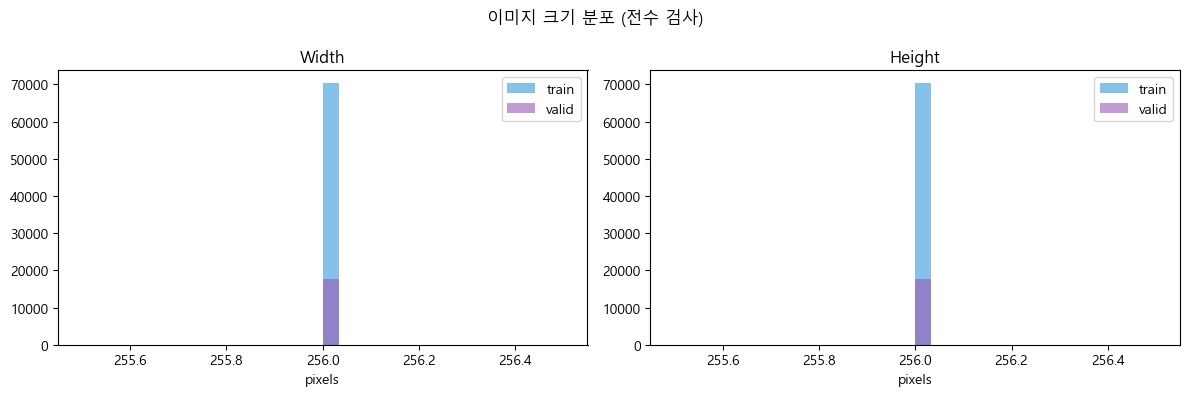

In [6]:
valid_quality = quality_df[~quality_df["is_broken"]].copy()

size_stats = valid_quality.groupby("split").agg(
    count=("path", "count"),
    width_min=("width", "min"),
    width_max=("width", "max"),
    width_mean=("width", "mean"),
    height_min=("height", "min"),
    height_max=("height", "max"),
    height_mean=("height", "mean"),
)
display(size_stats)

unique_sizes = (
    valid_quality.groupby(["width", "height"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)
print("Top 10 (width, height) 조합:")
display(unique_sizes.head(10))

is_224 = ((valid_quality["width"] == 224) & (valid_quality["height"] == 224)).sum()
print(f"\n224×224 이미지: {is_224:,} / {len(valid_quality):,} ({100 * is_224 / len(valid_quality):.2f}%)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, title in zip(axes, ["width", "height"], ["Width", "Height"]):
    for split, color in [("train", "#3498db"), ("valid", "#9b59b6")]:
        subset = valid_quality[valid_quality["split"] == split]
        ax.hist(subset[col], bins=30, alpha=0.6, label=split, color=color)
    ax.set_xlabel("pixels")
    ax.set_title(title)
    ax.legend()
plt.suptitle("이미지 크기 분포 (전수 검사)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "08_image_size_full.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. 클래스별 min/max · 불균형 분석

클래스별 이미지 수 — min / max / mean / std / CV
  min=2,052, max=2,527
  mean=2312.3, std=132.2
  CV=0.0572  (불균형 주의)


split,train_count,valid_count,total
class_name,,,
Soybean___healthy,2022,505,2527
Apple___Apple_scab,2016,504,2520
Orange___Haunglongbing_(Citrus_greening),2010,503,2513
Apple___healthy,2008,502,2510
"Pepper,_bell___healthy",1988,497,2485
Apple___Black_rot,1987,497,2484
Tomato___Tomato_Yellow_Leaf_Curl_Virus,1961,490,2451
Potato___Late_blight,1939,485,2424
Potato___Early_blight,1939,485,2424


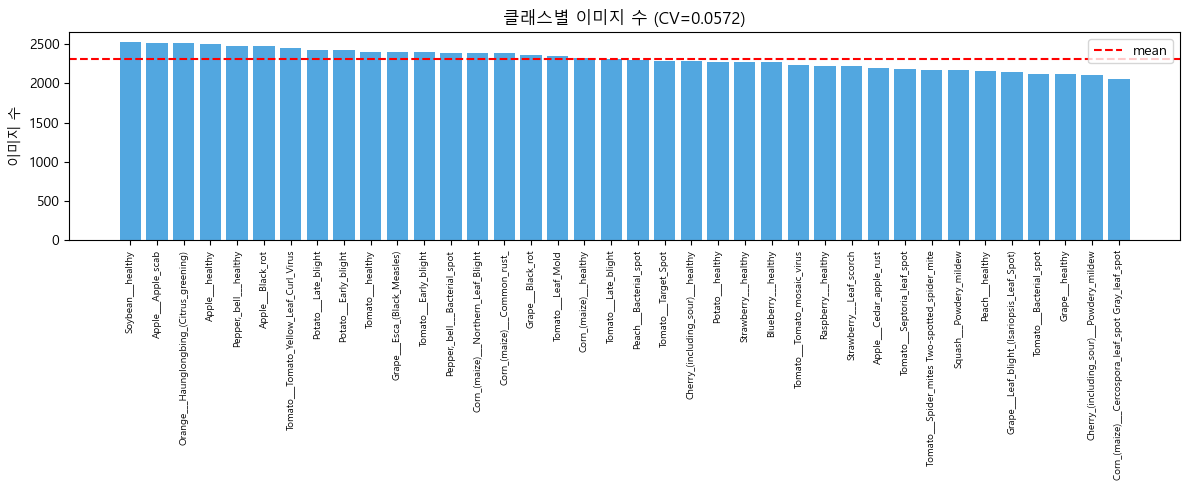

In [7]:
class_counts = (
    inventory_df.groupby(["class_name", "split"])
    .size()
    .unstack(fill_value=0)
    .rename(columns={"train": "train_count", "valid": "valid_count"})
)
class_counts["total"] = class_counts.sum(axis=1)
class_counts = class_counts.sort_values("total", ascending=False)

print("클래스별 이미지 수 — min / max / mean / std / CV")
print(f"  min={class_counts['total'].min():,}, max={class_counts['total'].max():,}")
print(f"  mean={class_counts['total'].mean():.1f}, std={class_counts['total'].std():.1f}")
cv = class_counts["total"].std() / class_counts["total"].mean()
print(f"  CV={cv:.4f}  {'(거의 균형)' if cv < 0.05 else '(불균형 주의)' if cv < 0.15 else '(불균형)'}")

display(class_counts)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(range(len(class_counts)), class_counts["total"], color="#3498db", alpha=0.85)
ax.set_xticks(range(len(class_counts)))
ax.set_xticklabels(class_counts.index, rotation=90, fontsize=7)
ax.set_ylabel("이미지 수")
ax.set_title(f"클래스별 이미지 수 (CV={cv:.4f})")
ax.axhline(class_counts["total"].mean(), color="red", linestyle="--", label="mean")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "09_class_imbalance.png", dpi=150, bbox_inches="tight")
plt.show()

class_counts.to_csv(OUTPUT_DIR / "04_class_counts.csv")

## 6. Train ↔ Valid 파일명 중복

동일 **파일명**이 train/valid 양쪽에 존재하는지 검사합니다. (클래스 폴더는 다를 수 있음)

In [8]:
train_names = set(inventory_df[inventory_df["split"] == "train"]["filename"])
valid_names = set(inventory_df[inventory_df["split"] == "valid"]["filename"])
name_overlap = sorted(train_names & valid_names)

print(f"Train 고유 파일명: {len(train_names):,}")
print(f"Valid 고유 파일명: {len(valid_names):,}")
print(f"양쪽 공통 파일명: {len(name_overlap):,}")

if name_overlap:
    overlap_df = inventory_df[inventory_df["filename"].isin(name_overlap)].sort_values(["filename", "split"])
    display(overlap_df.head(20))
    overlap_df.to_csv(OUTPUT_DIR / "05_filename_overlap.csv", index=False)
    print("⚠️ 동일 파일명이 train/valid 양쪽에 존재합니다. 내용 해시 검사(섹션 7)로 leakage 여부 확인하세요.")
else:
    print("✅ train/valid 간 동일 파일명 없음")

Train 고유 파일명: 70,295
Valid 고유 파일명: 17,572
양쪽 공통 파일명: 0
✅ train/valid 간 동일 파일명 없음


## 7. Train ↔ Valid 내용 해시(MD5) 중복 — Data Leakage 검사

Offline Augmentation 데이터셋은 **동일 원본**이 train/valid에 섞일 수 있습니다.  
`RUN_CONTENT_HASH_CHECK = True`일 때만 실행됩니다.

In [9]:
def md5_file(path: str, chunk_size: int = 8192) -> str:
    h = hashlib.md5()
    with open(path, "rb") as f:
        while chunk := f.read(chunk_size):
            h.update(chunk)
    return h.hexdigest()


leakage_df = pd.DataFrame()
hash_df = pd.DataFrame()
broken_paths = set(broken_df["path"]) if len(broken_df) > 0 else set()

if RUN_CONTENT_HASH_CHECK:
    hashes = []
    for row in tqdm(inventory_df.itertuples(index=False), total=len(inventory_df), desc="MD5 hash"):
        if row.path in broken_paths:
            continue
        try:
            file_hash = md5_file(row.path)
            hashes.append({
                "path": row.path,
                "filename": row.filename,
                "split": row.split,
                "class_name": row.class_name,
                "md5": file_hash,
            })
        except OSError as e:
            hashes.append({
                "path": row.path, "filename": row.filename, "split": row.split,
                "class_name": row.class_name, "md5": None, "error": str(e),
            })

    hash_df = pd.DataFrame(hashes)
    hash_df.to_csv(OUTPUT_DIR / "06_file_hashes.csv", index=False)

    valid_hash_df = hash_df[hash_df["md5"].notna()]
    train_hashes = valid_hash_df[valid_hash_df["split"] == "train"]
    valid_hashes = valid_hash_df[valid_hash_df["split"] == "valid"]
    shared_hashes = set(train_hashes["md5"]) & set(valid_hashes["md5"])

    print(f"고유 MD5 (train): {train_hashes['md5'].nunique():,}")
    print(f"고유 MD5 (valid): {valid_hashes['md5'].nunique():,}")
    print(f"Train ∩ Valid 공통 MD5: {len(shared_hashes):,}")

    if shared_hashes:
        leakage_rows = []
        for h in shared_hashes:
            t_rows = train_hashes[train_hashes["md5"] == h]
            v_rows = valid_hashes[valid_hashes["md5"] == h]
            for _, tr in t_rows.iterrows():
                for _, vr in v_rows.iterrows():
                    leakage_rows.append({
                        "md5": h,
                        "train_path": tr["path"],
                        "train_class": tr["class_name"],
                        "valid_path": vr["path"],
                        "valid_class": vr["class_name"],
                        "same_class": tr["class_name"] == vr["class_name"],
                    })
        leakage_df = pd.DataFrame(leakage_rows)
        leakage_df.to_csv(OUTPUT_DIR / "07_train_valid_leakage.csv", index=False)
        print(f"⚠️ Leakage 쌍: {len(leakage_df):,} (동일 픽셀 데이터가 train/valid 양쪽에 존재)")
        display(leakage_df.head(10))
    else:
        print("✅ Train/Valid 간 동일 MD5 없음 — content leakage 없음")

    dup_within = valid_hash_df.groupby(["split", "md5"]).size().reset_index(name="count")
    dup_within = dup_within[dup_within["count"] > 1]
    print(f"\nSplit 내부 중복 MD5 그룹: {len(dup_within):,} (offline aug 복제는 정상일 수 있음)")
else:
    print("RUN_CONTENT_HASH_CHECK=False — 해시 검사 생략")

MD5 hash:   0%|          | 0/87867 [00:00<?, ?it/s]

고유 MD5 (train): 70,277
고유 MD5 (valid): 17,570
Train ∩ Valid 공통 MD5: 6
⚠️ Leakage 쌍: 6 (동일 픽셀 데이터가 train/valid 양쪽에 존재)


,md5,train_path,train_class,valid_path,valid_class,same_class
0,5bdbdc7333be3ab35ef81ec17ce14816,C:\Users\user\Deep_Learning_Analysis\New Plant...,Tomato___Late_blight,C:\Users\user\Deep_Learning_Analysis\New Plant...,Tomato___Late_blight,True
1,926f8ebcfc60d44649018c5154c8fcec,C:\Users\user\Deep_Learning_Analysis\New Plant...,Apple___healthy,C:\Users\user\Deep_Learning_Analysis\New Plant...,Apple___healthy,True
2,ea0a44df2e4e44c6ccacc31f067a6284,C:\Users\user\Deep_Learning_Analysis\New Plant...,Tomato___healthy,C:\Users\user\Deep_Learning_Analysis\New Plant...,Tomato___healthy,True
3,161940bd6e73cf648974cc7213cffb8f,C:\Users\user\Deep_Learning_Analysis\New Plant...,Apple___healthy,C:\Users\user\Deep_Learning_Analysis\New Plant...,Apple___healthy,True
4,3dab5eb1192b5c43fd3015490cf0b18f,C:\Users\user\Deep_Learning_Analysis\New Plant...,Tomato___healthy,C:\Users\user\Deep_Learning_Analysis\New Plant...,Tomato___healthy,True
5,bf12be065849d781b7da2e79091b1072,C:\Users\user\Deep_Learning_Analysis\New Plant...,Tomato___Late_blight,C:\Users\user\Deep_Learning_Analysis\New Plant...,Tomato___Late_blight,True



Split 내부 중복 MD5 그룹: 20 (offline aug 복제는 정상일 수 있음)


## 8. OpenCV 로드 검증 (학습 파이프라인 호환)

`dataset.py`는 OpenCV(`cv2.imread`)로 이미지를 읽습니다. PIL과 결과가 다른 edge case가 있는지 **클래스당 1장** 샘플로 교차 검증합니다.

In [10]:
import random

rng = random.Random(42)
cv2_failures = []

for class_name in sorted(inventory_df["class_name"].unique()):
    paths = inventory_df[inventory_df["class_name"] == class_name]["path"].tolist()
    img_path = rng.choice(paths)
    img = cv2.imread(img_path)
    if img is None:
        cv2_failures.append({"path": img_path, "class_name": class_name, "error": "cv2.imread returned None"})
    elif len(img.shape) != 3 or img.shape[2] != 3:
        cv2_failures.append({"path": img_path, "class_name": class_name, "error": f"shape={img.shape}"})

cv2_fail_df = pd.DataFrame(cv2_failures)
print(f"OpenCV 로드 실패 (클래스당 1장 샘플, {inventory_df['class_name'].nunique()}장): {len(cv2_fail_df)}")
if len(cv2_fail_df) > 0:
    display(cv2_fail_df)
    cv2_fail_df.to_csv(OUTPUT_DIR / "08_cv2_load_failures.csv", index=False)
else:
    print("✅ OpenCV BGR 3채널 로드 정상 (샘플 검증)")

OpenCV 로드 실패 (클래스당 1장 샘플, 38장): 0
✅ OpenCV BGR 3채널 로드 정상 (샘플 검증)


## 9. Phase 2 품질 검증 보고서 저장

In [11]:
leakage_count = len(leakage_df)
name_overlap_count = len(name_overlap)

report = f"""
=== Phase 2 Data Quality Report ===

Dataset: {BASE_DIR}
Total files scanned: {len(inventory_df):,}

[1] Zero-byte files: {len(zero_byte):,}
[2] Broken images: {len(broken_df):,} ({100 * len(broken_df) / max(len(quality_df), 1):.4f}%)
[3] Non-RGB images: {len(non_rgb_df):,}
[4] 224×224 images: {is_224:,} / {len(valid_quality):,} ({100 * is_224 / max(len(valid_quality), 1):.2f}%)
[5] Class count CV: {cv:.4f}
[6] Filename overlap (train∩valid): {name_overlap_count:,}
[7] Content hash leakage pairs: {leakage_count:,}
[8] OpenCV sample load failures: {len(cv2_fail_df):,}

Pass criteria (recommended):
  - Broken images = 0
  - All RGB mode
  - 224×224 unified (or Resize in pipeline)
  - CV < 0.05 (balanced classes)
  - Leakage pairs = 0 (or documented & accepted)

Outputs: {OUTPUT_DIR}
Figures: {FIGURES_DIR}
"""

print(report)
(OUTPUT_DIR / "quality_report.txt").write_text(report.strip(), encoding="utf-8")

# 요약 테이블
summary_table = pd.DataFrame([
    {"check": "zero_byte", "count": len(zero_byte), "status": "PASS" if len(zero_byte) == 0 else "FAIL"},
    {"check": "broken_images", "count": len(broken_df), "status": "PASS" if len(broken_df) == 0 else "FAIL"},
    {"check": "non_rgb", "count": len(non_rgb_df), "status": "PASS" if len(non_rgb_df) == 0 else "WARN"},
    {"check": "not_224x224", "count": len(valid_quality) - is_224, "status": "PASS" if is_224 == len(valid_quality) else "INFO"},
    {"check": "filename_overlap", "count": name_overlap_count, "status": "PASS" if name_overlap_count == 0 else "WARN"},
    {"check": "hash_leakage_pairs", "count": leakage_count, "status": "PASS" if leakage_count == 0 else "WARN"},
    {"check": "cv2_load_failures", "count": len(cv2_fail_df), "status": "PASS" if len(cv2_fail_df) == 0 else "FAIL"},
])
display(summary_table)
summary_table.to_csv(OUTPUT_DIR / "quality_summary.csv", index=False)
print("Done.")


=== Phase 2 Data Quality Report ===

Dataset: C:\Users\user\Deep_Learning_Analysis\New Plant Diseases Dataset(Augmented)\New Plant Diseases Dataset(Augmented)
Total files scanned: 87,867

[1] Zero-byte files: 0
[2] Broken images: 0 (0.0000%)
[3] Non-RGB images: 0
[4] 224×224 images: 0 / 87,867 (0.00%)
[5] Class count CV: 0.0572
[6] Filename overlap (train∩valid): 0
[7] Content hash leakage pairs: 6
[8] OpenCV sample load failures: 0

Pass criteria (recommended):
  - Broken images = 0
  - All RGB mode
  - 224×224 unified (or Resize in pipeline)
  - CV < 0.05 (balanced classes)
  - Leakage pairs = 0 (or documented & accepted)

Outputs: C:\Users\user\Deep_Learning_Analysis\eda\outputs\phase2
Figures: C:\Users\user\Deep_Learning_Analysis\eda\figures



,check,count,status
0,zero_byte,0,PASS
1,broken_images,0,PASS
2,non_rgb,0,PASS
3,not_224x224,87867,INFO
4,filename_overlap,0,PASS
5,hash_leakage_pairs,6,WARN
6,cv2_load_failures,0,PASS


Done.
